<a href="https://colab.research.google.com/github/erichilarysmithsr/Colab-TWIMAH-Model/blob/main/TWIMAHModel.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Cell 1: Install and Import
# Unconditionally install modsim to ensure the correct modsim library is present (though it might not be the intended simulation library, it's benign)
!pip install modsim
!pip install dropbox

import pandas as pd
import numpy as np
import json
from scipy.interpolate import interp1d

In [ ]:
# Cell 0: Custom ModSim-like Utilities
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

class System(object):
    def __init__(self, **kwargs):
        self.__dict__.update(kwargs)

def run_solve_ivp(system, slope_func, **kwargs):
    t_span = [system.t_0, system.t_end]

    # Initialize X0 if not present in system, assuming 0.0 as a default
    if not hasattr(system, 'X0'):
        system.X0 = 0.0

    y_0 = [system.G0, system.X0]

    sol = solve_ivp(slope_func, t_span, y_0, args=(system,), **kwargs)

    # Extract results into a pandas DataFrame (mimicking modsim's TimeSeries)
    results = pd.DataFrame(index=sol.t)
    results['G'] = sol.y[0]
    results['X'] = sol.y[1]

    # 'details' can be the full solution object for debugging or further analysis
    return results, sol

def decorate(**kwargs):
    for key, value in kwargs.items():
        if key == 'title':
            plt.title(value)
        elif key == 'xlabel':
            plt.xlabel(value)
        elif key == 'ylabel':
            plt.ylabel(value)
    plt.legend()
    plt.grid(True)

# Cell 2: Environmental Parameters (RapidAPI/Research Simulation)
# We quantify "Urban Friction" (fu) based on food access density
case_001_env = {
    "zip_code": "60624",
    "neighborhood": "West Garfield Park",
    "glucotoxic_points": 14, # Fast food/liquor stores within 0.5 miles
    "stabilizer_points": 1,  # Legler Regional Library Food Pantry
    "transit_friction": 0.8, # Scale 0-1 (High due to CTA reliability issues)
    "snap_stress_index": 0.9  # High due to Feb 2026 work requirements
}

# This data will be saved to your TRANCEFormation Dropbox folder later

In [ ]:
# Cell 3: The Differential Equations
def slope_func(t, state, system):
    G, X = state

    # Calculate Insulin (I) from our 10g-Cap Interp function
    I = system.I(t)

    # Differential Equations (Minimal Model)
    # k3 is our "Stress Variable"
    dGdt = -system.k1 * (G - system.Gb) - X * G
    dXdt = system.k3 * (I - system.Ib) - system.k2 * X

    return dGdt, dXdt

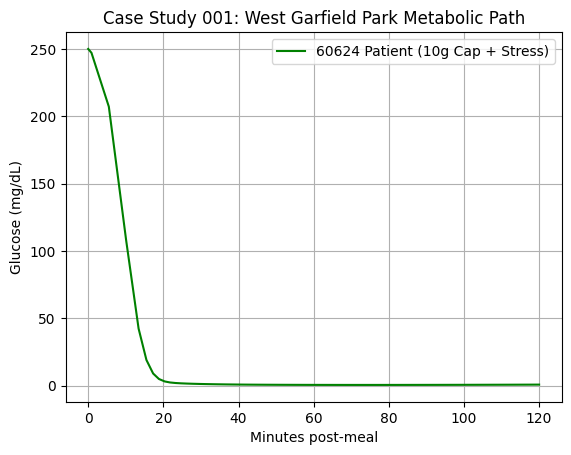

In [ ]:
# Cell 4: Running the simulation
# 10g Cap Insulin Response (Legler Library Pantry Meal: Tuna/Beans)
i_data = [10, 22, 28, 24, 18, 14, 12]
times = np.linspace(0, 120, len(i_data))
# Using scipy.interpolate.interp1d as make_interp_func is not found
I_func = interp1d(times, i_data, kind='linear', fill_value='extrapolate')

system = System(
    k1=0.02, k2=0.02,
    k3=0.0075, # 50% reduction due to "West Side Friction"
    Gb=90, Ib=10, G0=250, t_0=0, t_end=120,
    I=I_func
)

results, details = run_solve_ivp(system, slope_func)
results.G.plot(label='60624 Patient (10g Cap + Stress)', color='green')
decorate(title='Case Study 001: West Garfield Park Metabolic Path',
         xlabel='Minutes post-meal', ylabel='Glucose (mg/dL)')